In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [27]:
df = pd.read_csv("/content/heart.csv")

In [28]:
#xem 5 dòng đầu của dữ liệu
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [29]:
#kiểm tra có bao nhiêu giá trị bị thiếu
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [30]:
#kiểm tra có bao nhiêu dòng bị trùng
df.duplicated().sum()

np.int64(723)

In [31]:
#Kiểm tra số dòng, cột
df.shape

(1025, 14)

In [32]:
#kiểm tra dữ liệu xme có thiếu không
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [33]:
#thông kê
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [34]:
#đếm số lượng 0-1
df['target'].value_counts()

,count
target,
1,526
0,499


In [35]:
#rung bình đặc trưng giữa 0 bệnh-có bệnh
df.groupby('target').mean()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
target,,,,,,,,,,,,,
0,56.569138,0.827655,0.482966,134.106212,251.292585,0.164329,0.456914,139.130261,0.549098,1.600200,1.166333,1.158317,2.539078
1,52.408745,0.570342,1.378327,129.245247,240.979087,0.134981,0.598859,158.585551,0.134981,0.569962,1.593156,0.370722,2.119772


<Axes: >

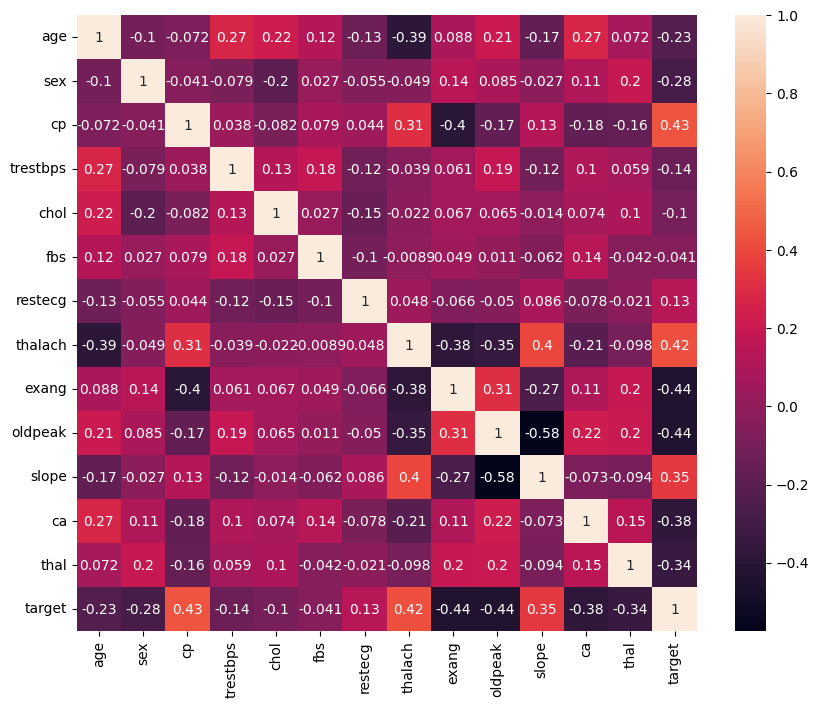

In [36]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)

In [37]:
#Chia feature thành hai
categorical = ['sex','cp','fbs','restecg','exang','slope','ca','thal']
continuous = ['age','trestbps','chol','thalach','oldpeak']

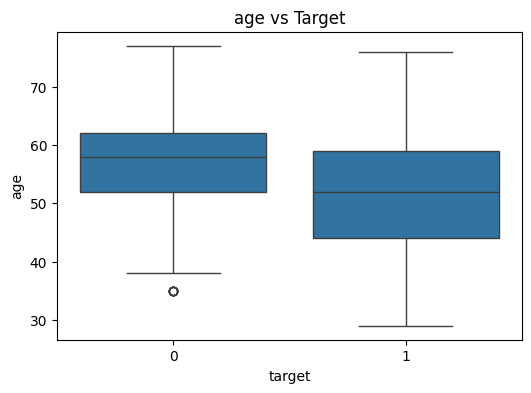

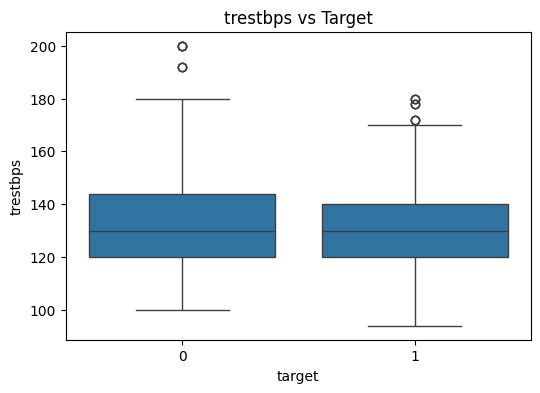

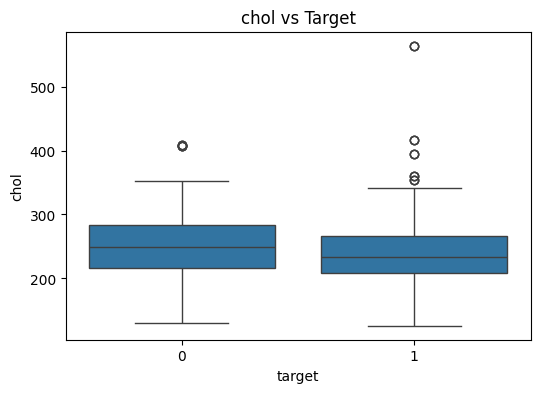

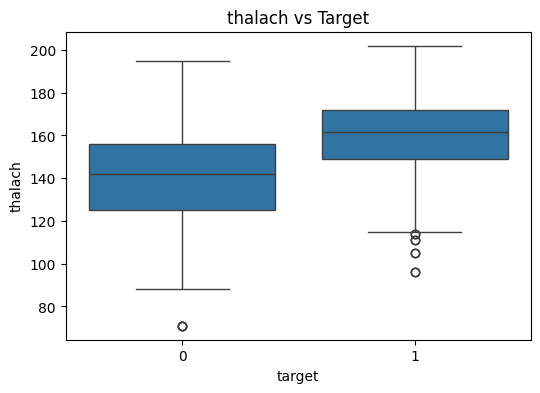

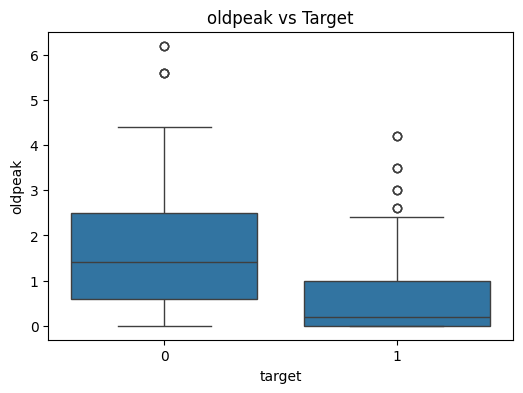

In [38]:
#So sanh phân bố theo target
for col in continuous:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} vs Target')
    plt.show()

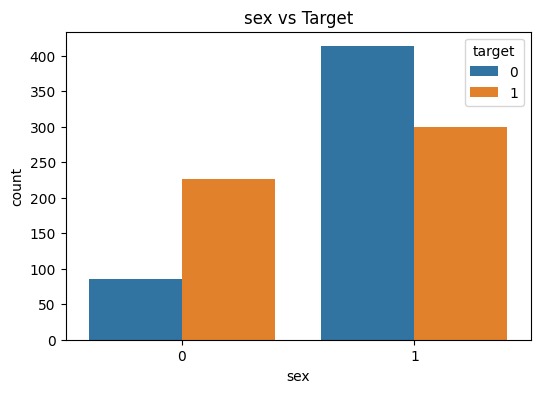

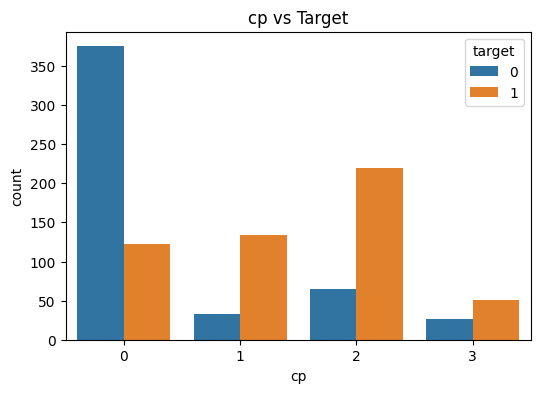

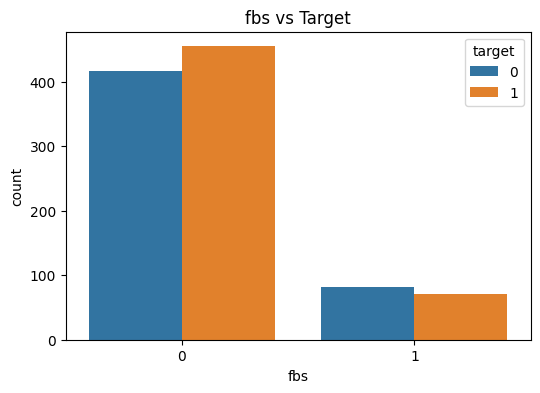

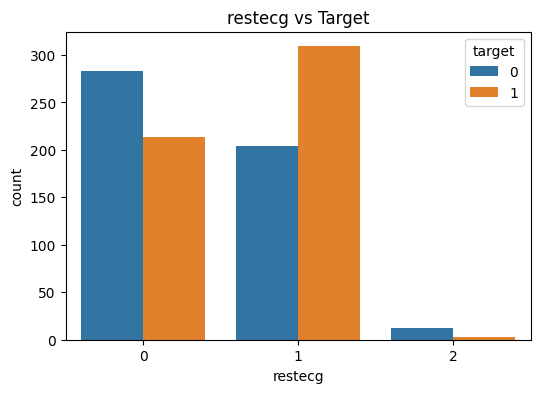

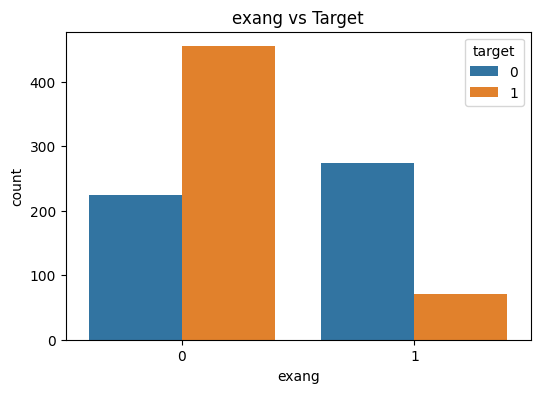

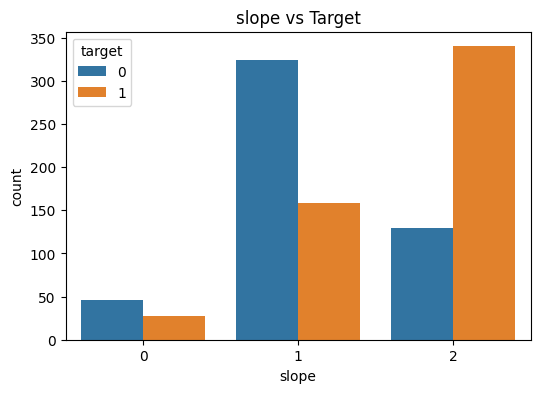

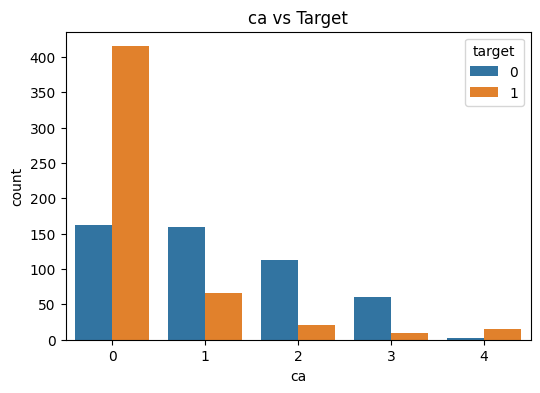

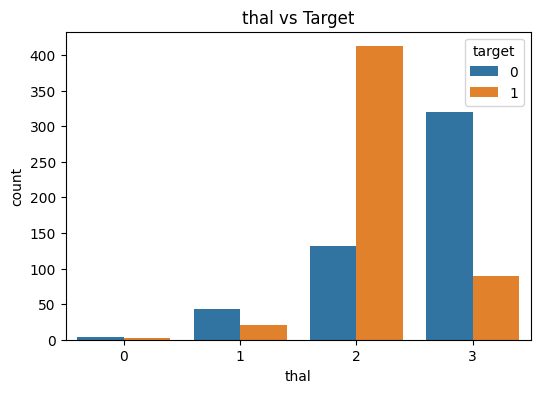

In [39]:
#đếm số lượng giá trị 0,1,2,.. để so sánh vs target
for col in categorical:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='target', data=df)
    plt.title(f'{col} vs Target')
    plt.show()

In [40]:
#tách x,y
X= df.drop(columns='target',axis=1)
y=df['target']

In [41]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2


In [42]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


In [43]:
#chia train/test 0.2=80%train, 20%test
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
X_train.shape, X_test.shape

((820, 13), (205, 13))

In [45]:
y_train.shape, y_test.shape

((820,), (205,))

In [46]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [47]:
X_train_std= scaler.fit_transform(X_train)
X_test_std= scaler.transform(X_test)

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [50]:
X_train_std

array([[-0.58584022,  0.65465367,  1.008275  , ...,  1.00526437,
         2.17169136, -0.54519316],
       [ 1.05147737, -1.52752523, -0.91672034, ...,  1.00526437,
        -0.7254674 , -0.54519316],
       [-0.04006769, -1.52752523,  1.008275  , ...,  1.00526437,
        -0.7254674 , -0.54519316],
       ...,
       [-0.36753121,  0.65465367, -0.91672034, ...,  1.00526437,
        -0.7254674 ,  1.11057867],
       [-1.24076726,  0.65465367, -0.91672034, ...,  1.00526437,
        -0.7254674 ,  1.11057867],
       [-0.2583767 ,  0.65465367, -0.91672034, ...,  1.00526437,
         0.24025219, -0.54519316]])

In [51]:
X_test_std

array([[ 0.83316836, -1.52752523, -0.91672034, ...,  1.00526437,
        -0.7254674 , -0.54519316],
       [-0.1492222 , -1.52752523,  1.008275  , ...,  1.00526437,
        -0.7254674 , -3.85673683],
       [ 0.06908682,  0.65465367, -0.91672034, ..., -0.64007851,
         0.24025219,  1.11057867],
       ...,
       [-1.13161275,  0.65465367,  1.008275  , ...,  1.00526437,
        -0.7254674 , -0.54519316],
       [ 0.72401385,  0.65465367, -0.91672034, ...,  1.00526437,
         0.24025219,  1.11057867],
       [ 0.39655033,  0.65465367,  1.008275  , ..., -0.64007851,
         0.24025219,  1.11057867]])

In [52]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

In [53]:
model = keras.Sequential([
    keras.layers.Input(shape=(13,)),
    keras.layers.Dense(12, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [54]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [55]:
history=model.fit(X_train_std,y_train,validation_split=0.2,epochs=100,batch_size=16)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4405 - loss: 0.7517 - val_accuracy: 0.4939 - val_loss: 0.7012
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5320 - loss: 0.6894 - val_accuracy: 0.5854 - val_loss: 0.6629
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5945 - loss: 0.6530 - val_accuracy: 0.6402 - val_loss: 0.6307
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7073 - loss: 0.5957 - val_accuracy: 0.6951 - val_loss: 0.5982
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7530 - loss: 0.5522 - val_accuracy: 0.7317 - val_loss: 0.5673
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7729 - loss: 0.5228 - val_accuracy: 0.7317 - val_loss: 0.5329
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7957 - loss: 0.4849 - val_accuracy: 0.7439 - val_loss: 0.5057
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7988 - loss: 0.4446 - val_accuracy: 0.7439 - 

In [56]:
#đánh giá model
loss, accuracy= model.evaluate(X_test_std,y_test)
print(accuracy)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8146 - loss: 0.3710 
0.8146341443061829


In [57]:
y_pred = model.predict(X_test_std)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [58]:
#chuyển về 0-1
y_pred = (y_pred > 0.5)

In [59]:
#Ý nghĩa :

#TP (True Positive) → dự đoán đúng người bị bệnh

#TN (True Negative) → dự đoán đúng người không bệnh

#FP (False Positive) → báo nhầm là có bệnh

#FN (False Negative) → NGUY HIỂM: có bệnh mà đoán không
#precision → độ chính xác khi dự đoán là bệnh

#recall → bắt được bao nhiêu người bệnh

#f1-score → cân bằng giữa precision & recall
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[75 27]
 [11 92]]
              precision    recall  f1-score   support

           0       0.87      0.74      0.80       102
           1       0.77      0.89      0.83       103

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



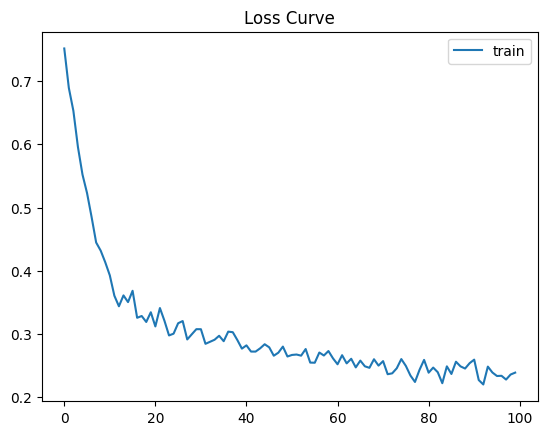

In [60]:
plt.plot(history.history['loss']) #độ sai model
plt.legend(['train'])
plt.title("Loss Curve")
plt.show()

In [61]:
import joblib

In [62]:
joblib.dump(model, "best_model.pkl")

['best_model.pkl']

In [63]:
model.save("best_model.keras")

In [64]:
from tensorflow.keras.models import load_model

model = load_model("best_model.keras")

In [ ]:
# ===== Nhập dữ liệu từ người dùng =====
print("Nhập thông tin người cần dự đoán:")

age = float(input("Age: "))
sex = int(input("Sex (1=male, 0=female): "))
cp = int(input("Chest Pain type (0-3): "))
trestbps = float(input("Resting Blood Pressure: "))
chol = float(input("Cholesterol: "))
fbs = int(input("Fasting Blood Sugar >120 (1=yes, 0=no): "))
restecg = int(input("Rest ECG (0-2): "))
thalach = float(input("Max Heart Rate: "))
exang = int(input("Exercise Angina (1=yes, 0=no): "))
oldpeak = float(input("Oldpeak: "))
slope = int(input("Slope (0-2): "))
ca = int(input("Number of vessels (0-3): "))
thal = int(input("Thal (0-3): "))

# ===== Tạo input =====
import numpy as np

input_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                        restecg, thalach, exang, oldpeak,
                        slope, ca, thal]])

# ===== Dùng scaler CŨ =====
input_data_std = scaler.transform(input_data)

# ===== Dự đoán =====
prediction = model.predict(input_data_std)
prediction = (prediction > 0.5).astype(int)

# ===== Kết quả =====
if prediction[0][0] == 1:
    print("⚠️ Người này CÓ nguy cơ mắc bệnh tim")
else:
    print("✅ Người này KHÔNG có nguy cơ mắc bệnh tim")

prob = model.predict(input_data_std)[0][0]
print("Xác suất mắc bệnh:", prob)

Nhập thông tin người cần dự đoán:
